---
authors:
  - name: Juan Henao
  - name: Lukas Heumos
    roles:
      - writing – review & editing
---


(air-repertoire-clonotype)=
# Clonotype analysis
```{dropdown} 🧠 Key takeaways

:::{card}
:link: #air-repertoire-clonotype-key-takeaway-1
Clonotypes group cells that descend from the same lymphocyte, and their expansion reveals which cells responded to an antigen.
:::

:::{card}
:link: #air-repertoire-clonotype-key-takeaway-2
The number of clonotypes depends on the number of sampled cells, so repertoires are better compared by evenness, which varies strongly between donors.
:::

:::{card}
:link: #air-repertoire-clonotype-key-takeaway-3
B cell clonotypes are defined by similar junctions with the same V and J genes, since somatic hypermutation changes the receptors within a clone.
:::

```
``````{dropdown} ⚙️ Environment setup
`````{tab-set}

````{tab-item} Steps
```{include} ../_static/default_text_env_setup.md
```
````

````{tab-item} yml
```{literalinclude} air_repertoire.yml
:language: yaml
```
````

`````
``````
````{dropdown} 🗄️ Get data and notebooks
```{include} ../_static/default_text_lamindb_setup.md
```
````
<!-- END DROPDOWNS -->


(air-repertoire-clonotype-key-takeaway-1)=
## Motivation

When a T or B cell recognizes its antigen, it proliferates into a clone of cells that share the receptor of their ancestor.
Grouping cells into {term}`clonotypes <Clonotype>` therefore reveals which cells expanded in an immune response, how they differentiated and how diverse a repertoire is.
There is no consensus definition of a clonotype for single-cell data {cite:p}`air:mhanna2024adaptive`, and TCRs and BCRs need different definitions, since only BCRs mutate after activation.

In [1]:
import warnings

import anndata as ad
import lamindb as ln
import scirpy as ir

warnings.filterwarnings("ignore", category=ad.ExperimentalFeatureWarning)

ln.connect("theislab/sc-best-practices")

ln.track("vISuAyonHdGO")

→ connected lamindb: theislab/sc-best-practices


! It looks like you are running jupyter lab but don't have jupyter-server module installed. Please install it via pip install jupyter-server


→ loaded Transform('vISuAyonHdGO0000', key='clonotype.ipynb'), started new Run('JlAriU0dhHFEp8c5') at 2026-09-29 18:09:53 UTC


→ notebook imports: anndata==0.13.2 lamindb-core==2.10.0 scirpy==0.25.1


We load the T and B cells that passed [quality control](ir_profiling.ipynb).

In [2]:
mdata_tcr = ln.Artifact.get(key="air_repertoire/stephenson2021_tcr_qc.h5mu").load()
mdata_bcr = ln.Artifact.get(key="air_repertoire/stephenson2021_bcr_qc.h5mu").load()

## T cell clonotypes

Cells of the same T cell clone have identical receptors, so we group cells whose primary α and β chains have identical CDR3 nucleotide sequences.
Cells without both chains remain unassigned, since an orphan chain cannot be told apart from a different receptor that shares it.
We do not merge cells of different donors, whose identical TCRs arose independently.

In [3]:
ir.pp.ir_dist(mdata_tcr)
ir.tl.define_clonotypes(
    mdata_tcr,
    receptor_arms="all",
    dual_ir="primary_only",
    within_group="gex:patient_id",
)
ir.tl.clonal_expansion(mdata_tcr)
mdata_tcr.pull_obs()

`clonal_expansion` labels each cell by the size of its clonotype, which we compare between cell types.

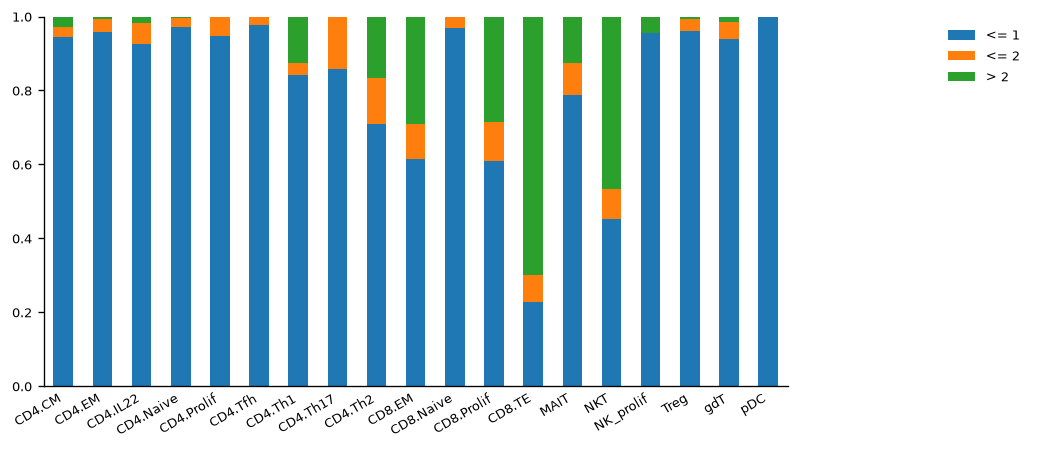

In [4]:
_ = ir.pl.clonal_expansion(mdata_tcr, groupby="gex:cell_type", figsize=(8, 4))

About 70% of terminal effector CD8+ T cells (CD8.TE) belong to clonotypes of more than two cells, followed by NKT cells and effector memory and proliferating CD8+ T cells.
Naive T cells are almost never expanded, as expected for cells that have not encountered their antigen.

## Gene usage

V genes are not used uniformly, and their usage is shaped by selection {cite:p}`air:elhanati2014quantifying`.
A striking example are mucosal-associated invariant T (MAIT) cells, which recognize a conserved bacterial metabolite with a semi-invariant α chain built from TRAV1-2 {cite:p}`air:reantragoon2013antigen`.
`airr_context` temporarily adds chain fields such as the V gene to `.obs`.

In [5]:
with ir.get.airr_context(mdata_tcr, "v_call"):
    trav1_2 = mdata_tcr.obs["VJ_1_v_call"] == "TRAV1-2"
trav1_2.groupby(mdata_tcr.obs["gex:cell_type_coarse"], observed=True).mean()

gex:cell_type_coarse
CD4             0.004050
CD8             0.025099
Lymph_prolif    0.036866
MAIT            0.691238
Treg            0.007282
gdT             0.018349
Name: VJ_1_v_call, dtype: float64

About 70% of MAIT cells use TRAV1-2, compared to a few percent of the other T cells, so the TCR confirms the transcriptomic annotation of these cells.

(air-repertoire-clonotype-key-takeaway-2)=
## Diversity

Clonal expansion reduces the diversity of a repertoire.
The number of clonotypes grows with the number of sampled cells, which differs between donors, so we instead compare how evenly the cells are distributed across clonotypes.
The Shannon entropy normalized by the number of clonotypes measures this evenness and is among the indices that are least affected by subsampling {cite:p}`air:mika2025diversity`.
We compute it for the CD8+ T cells of each donor, which contain most expanded clonotypes.

In [6]:
cd8 = mdata_tcr[mdata_tcr.obs["gex:cell_type_coarse"] == "CD8"]
diversity = ir.tl.alpha_diversity(cd8, groupby="gex:patient_id", inplace=False)
severity = cd8.obs.groupby("gex:patient_id", observed=True)["gex:severity"].first()
diversity.columns = ["evenness"]
diversity.join(severity).groupby("gex:severity", observed=True).agg(
    ["median", "min", "max"]
).loc[["Healthy", "Asymptomatic", "Mild", "Moderate", "Severe", "Critical"]]

evenness                    
                median       min       max
gex:severity                              
Healthy       0.986247  0.708246  0.999646
Asymptomatic  0.971843  0.832017  0.997485
Mild          0.987283  0.816396  0.998319
Moderate      0.906214  0.808433  0.988063
Severe        0.923813  0.915976  1.000000
Critical      0.980684  0.960805  0.997798

The evenness is close to 1 for most donors, but a few donors in most groups, including healthy donors, carry strongly expanded clonotypes.
These differences between donors are larger than those between severity groups, so comparing groups requires many donors and has to consider expansions against latent viruses such as cytomegalovirus, which we look at in the [specificity chapter](specificity.ipynb).

(air-repertoire-clonotype-key-takeaway-3)=
## B cell clonotypes

BCRs of the same clone differ by somatic hypermutation, so grouping identical sequences would split clonal families {cite:p}`air:balashova2024systematic`.
Instead, BCRs with the same V and J genes and junction length are clustered by the Hamming distance of their junction nucleotides, which identifies clones with high sensitivity and specificity {cite:p}`air:gupta2017hierarchical`.
We use a normalized Hamming distance of at most 15% of the junction length and require both heavy and light chains to match, since the light chain separates clones that share a similar heavy chain {cite:p}`air:jaffe2022functional`.

In [7]:
ir.pp.ir_dist(mdata_bcr, metric="normalized_hamming", cutoff=15, sequence="nt")
ir.tl.define_clonotype_clusters(
    mdata_bcr,
    sequence="nt",
    metric="normalized_hamming",
    receptor_arms="all",
    dual_ir="any",
    same_v_gene=True,
    same_j_gene=True,
    within_group="gex:patient_id",
    key_added="clone_id",
)
ir.tl.clonal_expansion(mdata_bcr)
mdata_bcr.pull_obs()

/home/lheumos/miniforge3/envs/air-repertoire/lib/python3.13/site-packages/scirpy/ir_dist/metrics.py:751: NumbaTypeSafetyWarning: unsafe cast from uint64 to int64. Precision may be lost.
  data_rows[row_index][0] = data_row_matrix[thread_id, 0:row_end_index].copy()


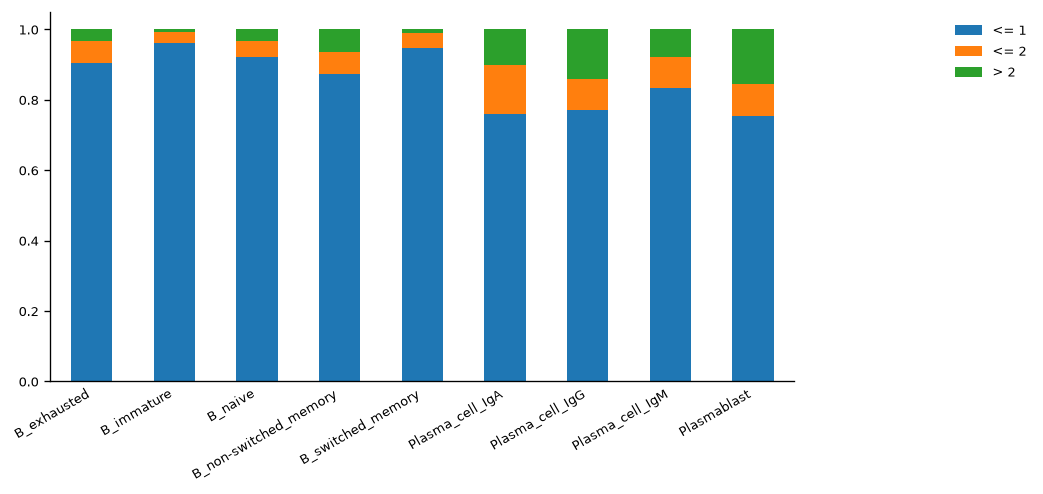

In [8]:
_ = ir.pl.clonal_expansion(mdata_bcr, groupby="gex:cell_type", figsize=(8, 4))

Plasmablasts and plasma cells are most often clonally expanded, since they arise from B cells that proliferated after encountering their antigen.
Naive and immature B cells are rarely expanded.

## Isotypes and somatic hypermutation

The constant gene of the heavy chain determines the isotype of a B cell.
Somatic hypermutation is measured by comparing the V gene of each BCR with its reconstructed germline, which `mutational_load` does for the whole sequence and each of its regions.

gex:cell_type
B_exhausted              0.032051
B_immature                    0.0
B_naive                       0.0
B_non-switched_memory    0.032051
B_switched_memory        0.059295
Plasma_cell_IgA          0.067308
Plasma_cell_IgG          0.051282
Plasma_cell_IgM          0.003205
Plasmablast              0.044872
Name: VDJ_1_v_mutation_freq, dtype: Float64

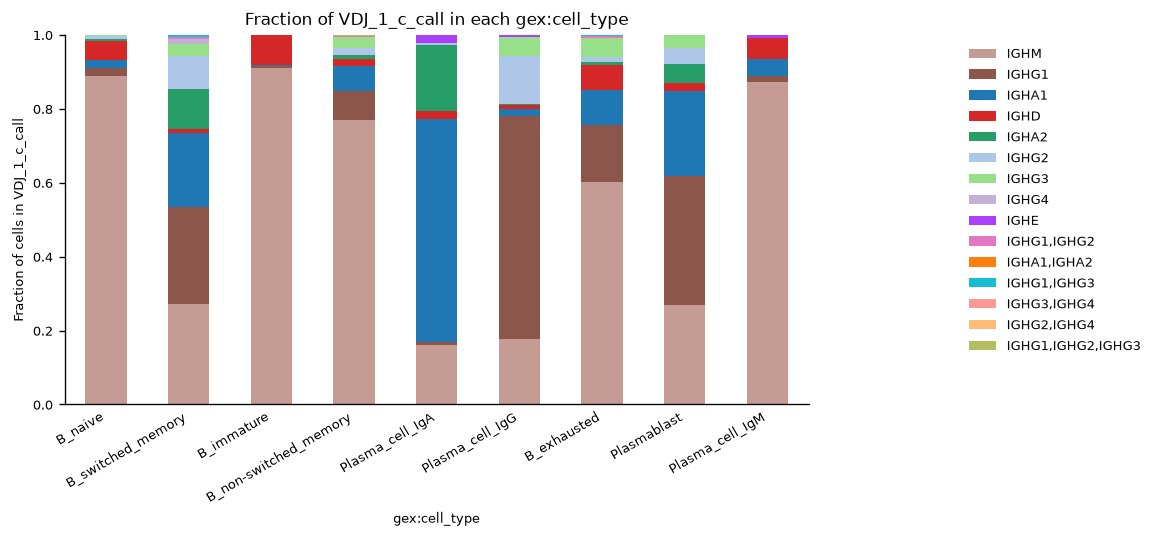

In [9]:
ir.tl.mutational_load(mdata_bcr)
with ir.get.airr_context(mdata_bcr, ["c_call", "v_mutation_freq"]):
    _ = ir.pl.group_abundance(
        mdata_bcr,
        groupby="gex:cell_type",
        target_col="VDJ_1_c_call",
        normalize=True,
        figsize=(8, 4),
    )
    mutation = mdata_bcr.obs.groupby("gex:cell_type", observed=True)[
        "VDJ_1_v_mutation_freq"
    ].median()
mutation

Naive and immature B cells express IgM and IgD and carry almost no mutations.
Switched memory B cells and IgA and IgG plasma cells have undergone class switching, and around 5% of the nucleotides of their V genes are mutated.

We store the clonotypes for the [specificity analysis](specificity.ipynb) and the [integration with gene expression](multimodal_integration.ipynb).

In [10]:
ln.Artifact.from_mudata(
    mdata_tcr,
    key="air_repertoire/stephenson2021_tcr_clonotypes.h5mu",
    description="T cells of the Stephenson 2021 Cambridge samples with clonotypes",
).save()
ln.Artifact.from_mudata(
    mdata_bcr,
    key="air_repertoire/stephenson2021_bcr_clonotypes.h5mu",
    description="B cells of the Stephenson 2021 Cambridge samples with clonotypes and mutational load",
).save()

→ returning artifact with same hash: Artifact(uid='Tfd4y2f2suUjTVPw0001', key='air_repertoire/stephenson2021_tcr_clonotypes.h5mu', description='T cells of the Stephenson 2021 Cambridge samples with clonotypes', suffix='.h5mu', kind='dataset', otype='MuData', size=759562317, hash='PmhNx3rxbtdTRTiPFqY0l0', n_files=None, n_observations=54137, extra_data=None, branch_id=1, created_on_id=1, space_id=1, storage_id=1, run_id=180, schema_id=None, created_by_id=2, created_at=2026-09-29 18:07:09 UTC, is_locked=False, version_tag=None, is_latest=True); to track this artifact as an input, use: ln.Artifact.get()


→ creating new artifact version for key 'air_repertoire/stephenson2021_bcr_clonotypes.h5mu' in storage 's3://lamin-eu-central-1/VPwcjx3CDAa2'


... uploading 9u5AeRoRPsXssywH0002.h5mu:  0.0%

... uploading 9u5AeRoRPsXssywH0002.h5mu: 16.0%

... uploading 9u5AeRoRPsXssywH0002.h5mu: 51.9%

... uploading 9u5AeRoRPsXssywH0002.h5mu: 84.0%

... uploading 9u5AeRoRPsXssywH0002.h5mu: 100.0%
• replacing the existing cache path /home/lheumos/.cache/lamindb/lamin-eu-central-1/VPwcjx3CDAa2/air_repertoire/stephenson2021_bcr_clonotypes.h5mu


Artifact(uid='9u5AeRoRPsXssywH0002', key='air_repertoire/stephenson2021_bcr_clonotypes.h5mu', description='B cells of the Stephenson 2021 Cambridge samples with clonotypes and mutational load', suffix='.h5mu', kind='dataset', otype='MuData', size=326684601, hash='HILCJa0SSlNPU7E8S3rQfu', n_files=None, n_observations=13422, extra_data=None, branch_id=1, created_on_id=1, space_id=1, storage_id=1, run_id=183, schema_id=None, created_by_id=2, created_at=2026-09-29 18:10:09 UTC, is_locked=False, version_tag=None, is_latest=True)

## Quiz

In [11]:
%run ../../scripts/quiz.py

with quiz_tabs():
    flip_card(
        "q1",
        "Why are BCR clonotypes defined by sequence similarity rather than identity?",
        "Somatic hypermutation changes the receptors of activated B cells, so cells of the same clone carry similar but not identical sequences.",
        back_font_size=15,
    )
    flip_card(
        "q2",
        "Which T cells are most often clonally expanded?",
        "Antigen-experienced effector and effector memory CD8+ T cells, whereas naive T cells are rarely expanded.",
        back_font_size=15,
    )
    flip_card(
        "q3",
        "Why is the number of clonotypes a poor measure for comparing repertoire diversity between samples?",
        "It grows with the number of sampled cells, so evenness measures such as the normalized Shannon entropy are more robust.",
        back_font_size=15,
    )

## Contributors

We gratefully acknowledge the contributions of:

### Authors

* Juan Henao

### Reviewers

* Lukas Heumos